In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import pandas as pd
import sys
sys.path.append("src")

from nlp_classic.classifier import run_nlp_classic

df = pd.read_csv("data/processed/labels.csv")
print(f"Dataset cargado: {df.shape}")

Dataset cargado: (4869, 4)


In [2]:
nb, lr, vec, y_test = run_nlp_classic(df)

Preprocesando textos...

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.57      0.45      0.50       244
     neutral       0.60      0.61      0.61       384
    positive       0.59      0.66      0.62       346

    accuracy                           0.59       974
   macro avg       0.59      0.57      0.58       974
weighted avg       0.59      0.59      0.59       974


=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.64      0.42      0.51       244
     neutral       0.60      0.72      0.65       384
    positive       0.65      0.67      0.66       346

    accuracy                           0.63       974
   macro avg       0.63      0.60      0.61       974
weighted avg       0.63      0.63      0.62       974


Resultados guardados en results/metrics_nlp_classic.json


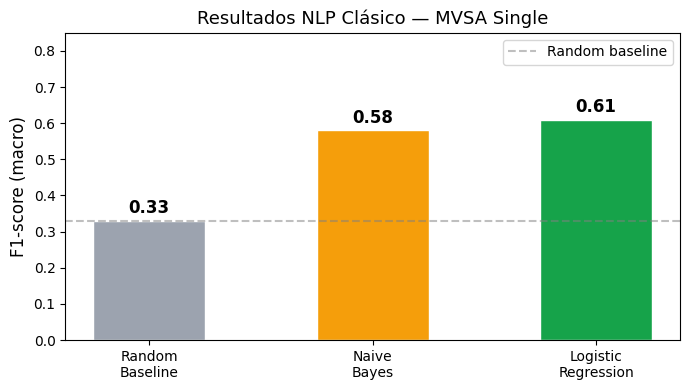

In [3]:
import matplotlib.pyplot as plt
import numpy as np

modelos   = ['Random\nBaseline', 'Naive\nBayes', 'Logistic\nRegression']
f1_scores = [0.33, 0.58, 0.61]
colors    = ['#9ca3af', '#f59e0b', '#16a34a']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(modelos, f1_scores, color=colors, width=0.5, edgecolor='white')

# Etiquetas encima de cada barra
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 0.85)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Resultados NLP Clásico — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/nlp_classic_results.png', dpi=150)
plt.show()

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import pandas as pd
import sys, os
sys.path.append("src")
from nlp_classic.preprocessing import TextPreprocessor

# Preprocesar textos
prep  = TextPreprocessor()
texts = [prep.preprocess(t) for t in df['text']]
labels = df['label'].tolist()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

# --- Grid Search Logistic Regression ---
print("Grid Search — Logistic Regression...")
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range':  [(1,1), (1,2), (1,3)],
    'tfidf__sublinear_tf': [True, False],
    'clf__C':              [0.1, 0.5, 1.0, 5.0, 10.0],
}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr,
                     cv=5, scoring='f1_macro',
                     n_jobs=-1, verbose=1)
gs_lr.fit(X_train, y_train)

print(f"\nMejores parámetros LR: {gs_lr.best_params_}")
print(f"Mejor F1 CV:           {gs_lr.best_score_:.4f}")

y_pred_lr = gs_lr.predict(X_test)
from sklearn.metrics import classification_report, f1_score
print("\n=== LR Optimizado ===")
print(classification_report(y_test, y_pred_lr))
print(f"F1 macro test: {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

Grid Search — Logistic Regression...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Mejores parámetros LR: {'clf__C': 5.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Mejor F1 CV:           0.6036

=== LR Optimizado ===
              precision    recall  f1-score   support

    negative       0.57      0.50      0.54       244
     neutral       0.61      0.65      0.63       384
    positive       0.64      0.64      0.64       346

    accuracy                           0.61       974
   macro avg       0.61      0.60      0.60       974
weighted avg       0.61      0.61      0.61       974

F1 macro test: 0.6017


In [5]:
# --- Grid Search Naive Bayes ---
print("Grid Search — Naive Bayes...")
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf',   MultinomialNB())
])

param_grid_nb = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'tfidf__sublinear_tf': [True, False],
    'clf__alpha':          [0.01, 0.05, 0.1, 0.5, 1.0],
}

gs_nb = GridSearchCV(pipe_nb, param_grid_nb,
                     cv=5, scoring='f1_macro',
                     n_jobs=-1, verbose=1)
gs_nb.fit(X_train, y_train)

print(f"\nMejores parámetros NB: {gs_nb.best_params_}")
print(f"Mejor F1 CV:           {gs_nb.best_score_:.4f}")

y_pred_nb = gs_nb.predict(X_test)
print("\n=== NB Optimizado ===")
print(classification_report(y_test, y_pred_nb))
print(f"F1 macro test: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")

Grid Search — Naive Bayes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Mejores parámetros NB: {'clf__alpha': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Mejor F1 CV:           0.5786

=== NB Optimizado ===
              precision    recall  f1-score   support

    negative       0.57      0.46      0.51       244
     neutral       0.60      0.61      0.60       384
    positive       0.60      0.67      0.63       346

    accuracy                           0.59       974
   macro avg       0.59      0.58      0.58       974
weighted avg       0.59      0.59      0.59       974

F1 macro test: 0.5799


In [6]:
# Guardar probabilidades optimizadas para la fusión
import json, numpy as np

results_opt = {
    'logistic_regression': {
        'f1_macro': f1_score(y_test, y_pred_lr, average='macro'),
        'best_params': gs_lr.best_params_,
        'report': classification_report(y_test, y_pred_lr, output_dict=True),
        'probas': gs_lr.predict_proba(X_test).tolist()
    },
    'naive_bayes': {
        'f1_macro': f1_score(y_test, y_pred_nb, average='macro'),
        'best_params': gs_nb.best_params_,
        'report': classification_report(y_test, y_pred_nb, output_dict=True)
    }
}

with open('results/metrics_nlp_classic.json', 'w') as f:
    json.dump(results_opt, f, indent=2)
print("Guardado en results/metrics_nlp_classic.json")

Guardado en results/metrics_nlp_classic.json
